## RIMO LFI and HFI values

Link - https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp

filename_lfi = "/bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits"
filename_hfi = "/bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits"
hdul_lfi = fits.open(filename_lfi)
hdul_hfi = fits.open(filename_hfi)


In [2]:
print(hdul_lfi.info())

Filename: /bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1  CHANNEL_PARAMETERS    1 BinTableHDU     62   22R x 15C   [8A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  FREQUENCY_MAP_PARAMETERS    1 BinTableHDU     48   3R x 10C   [3A, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   
  3  BANDPASS_030-28S    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  4  BANDPASS_030-28M    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  5  BANDPASS_030-27S    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  6  BANDPASS_030-27M    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  7  BANDPASS_044-26S    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
  8  BANDPASS_044-26M    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
  9  BANDPASS_044-25S    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
 10  BANDPASS_044-25M    1 BinTab

In [3]:
print(hdul_hfi.info())


Filename: /bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  HFI_RIMO      1 PrimaryHDU      14   ()      
  1  MAP_PARAMS    1 BinTableHDU     50   6R x 10C   [3A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  3  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  4  BANDPASS_F143    1 BinTableHDU     28   12602R x 3C   [1E, 1E, 1A]   
  5  BANDPASS_F217    1 BinTableHDU     28   12600R x 3C   [1E, 1E, 1A]   
  6  BANDPASS_F353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
  7  BANDPASS_F545    1 BinTableHDU     28   13938R x 3C   [1E, 1E, 1A]   
  8  BANDPASS_F857    1 BinTableHDU     28   16819R x 3C   [1E, 1E, 1A]   
  9  BANDPASS_PSB353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
None


In [4]:
bandpass_lfi = hdul_lfi['BANDPASS_030']
bandpass_hfi = hdul_hfi['BANDPASS_F857']
print(bandpass_lfi.columns)
print(bandpass_hfi.columns)

ColDefs(
    name = 'WAVENUMBER'; format = '1D'; unit = 'GHz'
    name = 'TRANSMISSION'; format = '1D'; unit = 'n/a'
    name = 'UNCERTAINITY'; format = '1E'; unit = 'n/a'
    name = 'FLAG'; format = '1A'; unit = 'n/a'; dim = '(1,1)'
)
ColDefs(
    name = 'WAVENUMBER'; format = '1E'; unit = '1/cm'
    name = 'TRANSMISSION'; format = '1E'; unit = 'n/a'
    name = 'FLAG'; format = '1A'; dim = '(1,1)'
)


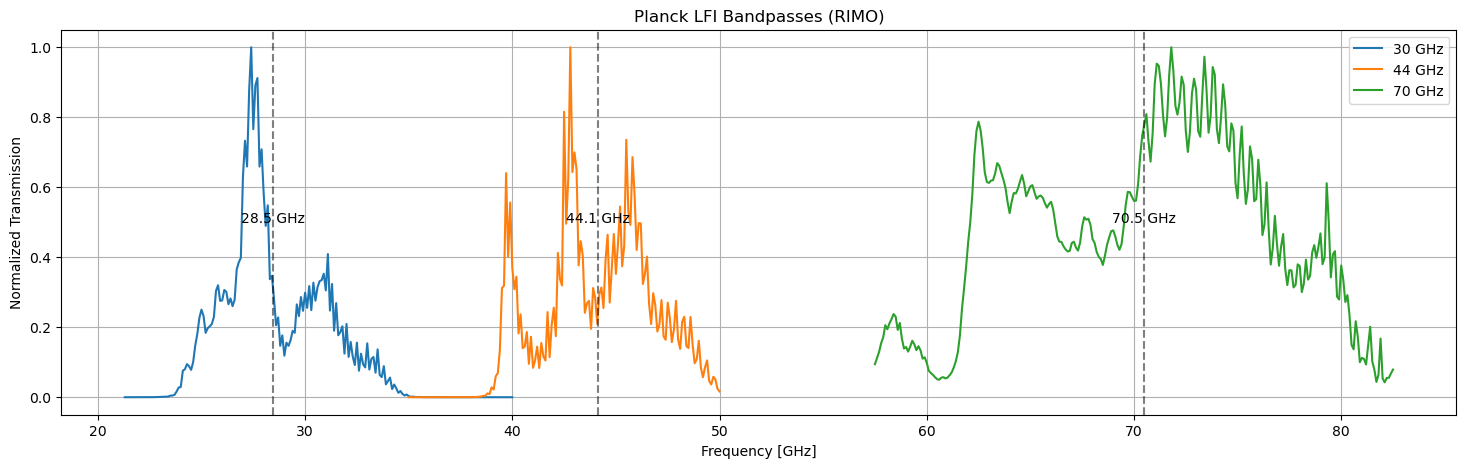

In [5]:
import matplotlib.pyplot as plt
from astropy import units as u

# Pick the bandpasses you care about
bandpasses = ["BANDPASS_030", "BANDPASS_044", "BANDPASS_070"]

plt.figure(figsize=(18,5))

for bp in bandpasses:
    hdu = hdul_lfi[bp]

    wn = hdu.data['WAVENUMBER'] * (1/u.cm)
    weights = hdu.data['TRANSMISSION'].astype(float)
    weights /= np.max(weights)   
    freq_eff = np.sum(wn * weights) / np.sum(weights)
    
    plt.plot(wn, weights, label=bp.replace("BANDPASS_0", "") + " GHz")
    plt.axvline(freq_eff.value, color='k', linestyle='--', alpha=0.5)
    plt.text(freq_eff.value, 0.5, f"{freq_eff.value:.1f} GHz", ha='center')
plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title("Planck LFI Bandpasses (RIMO)")
plt.legend()
plt.grid(True)
plt.show()


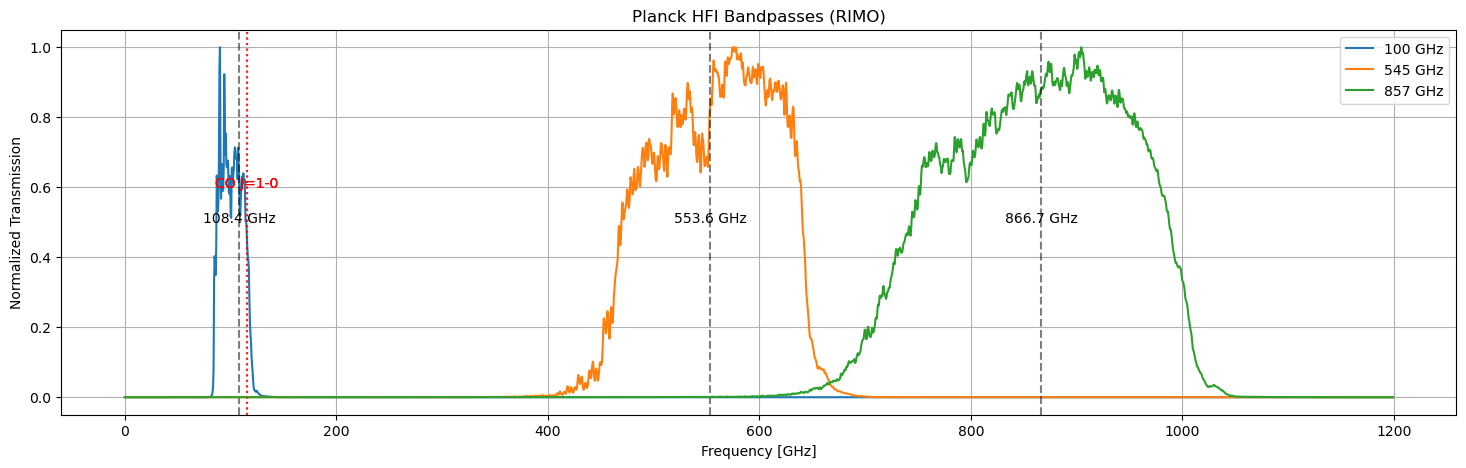

In [ ]:
bandpasses = ["BANDPASS_F100", "BANDPASS_F545", "BANDPASS_F857"]

plt.figure(figsize=(18,5))

for bp in bandpasses:
    hdu = hdul_hfi[bp]

    # converting wavenumber to frequency
    wn = hdu.data['WAVENUMBER'] * (1/u.cm)
    freqs = wn.to(u.GHz, equivalencies=u.spectral())
    
    mask = freqs < 1200 *u.GHz #im doing this masking because the freq values are till 17987.547 GHz and the plot looks bad
    freqs = freqs[mask]
    weights = hdu.data['TRANSMISSION'].astype(float)[mask]
    # wn = hdu.data['WAVENUMBER'] * (1/u.cm)
    # weights = hdu.data['TRANSMISSION'].astype(float)
    weights /= np.max(weights)   # normalize peak to 1 for easier comparison
    freq_eff = np.sum(freqs * weights) / np.sum(weights)
    plt.plot(freqs, weights, label=bp.replace("BANDPASS_F", "") + " GHz")
    plt.axvline(freq_eff.value, color='k', linestyle='--', alpha=0.5)
    plt.text(freq_eff.value, 0.5, f"{freq_eff.value:.1f} GHz", ha='center')

    plt.axvline(115.271,color='r',linestyle=':',alpha=0.5)
    plt.text(115.271, 0.6, "CO J=1-0", color='r', ha='center')


plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title("Planck HFI Bandpasses (RIMO)")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
def make_bandpass(center, width=1.0*u.GHz, n_points=50):
    freqs = center + np.linspace(-3, 3, n_points) * width
    weights = np.exp(-0.5 * ((freqs - center)/width)**2)
    weights /= np.sum(weights)
    return freqs, weights

## CO1 maps

In [8]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)
os.environ["CMB_ML_DATA"] = "/bigdata/cmb_project/data/"
sys.path.append("/bigdata/aankit/lost_in_space/")
os.environ['XDG_CONFIG_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_config'
os.environ['XDG_CACHE_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_cache'

from astropy.config.paths import get_cache_dir
print("Astropy cache dir:", get_cache_dir()) 

Astropy cache dir: /bigdata/cmb_project/xdg_home/xdg_cache/astropy


In [9]:
from time import time
import hydra
from hydra import compose, initialize

from cmbml.utils.planck_instrument import make_instrument
from cmbml_utils import PipeAccessor  # make sure to add ../lost_in_space to sys.path

import pysm3
import pysm3.units as u

from cmbml.core.asset_handlers import HealpyMap

In [10]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None)
cfg = compose(config_name='config_sim', overrides=["+min_obs_beam=0"])  # Only used for the instrument
pa = PipeAccessor(cfg, "raw_in")
sim_det_info = pa.assets_in['deltabandpass'].read()
SIM_INSTRUMENT = make_instrument(cfg=cfg,
                                 det_info=sim_det_info)

In [11]:
PRESET_STRINGS = ['co1']

NSIDE_SKY = 2048
NSIDE_OUT = 512

start = time()
sky = pysm3.Sky(nside=NSIDE_SKY, preset_strings=PRESET_STRINGS, output_unit=pysm3.units.uK_CMB)
print(f"Sky generation time: {time() - start:.2f}s" )

Sky generation time: 20.54s


## Using lazy bp method around 100GHz

Text(0.5, 1.0, 'Example Gaussian Bandpass')

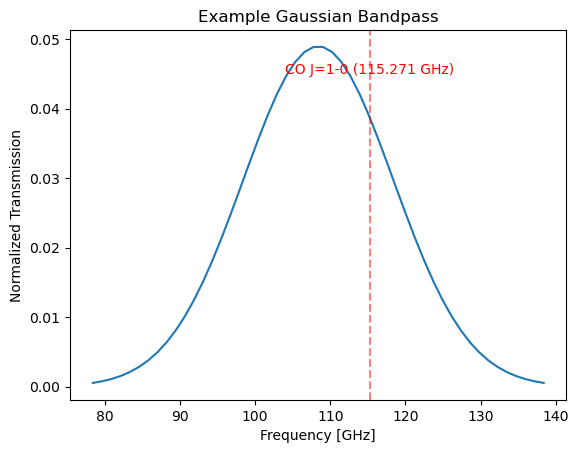

In [12]:
lazy_freqs, lazy_weights = make_bandpass(108.4*u.GHz, width=10*u.GHz, n_points=50)
plt.plot(lazy_freqs.value, lazy_weights)
plt.axvline(115.271, color='r', linestyle='--', alpha=0.5)
plt.text(115.271, 0.045, "CO J=1-0 (115.271 GHz)", color='r', ha='center')
plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title("Example Gaussian Bandpass")

In [13]:
start = time()
co_map = sky.get_emission(lazy_freqs,lazy_weights)
print("CO map making time:", time() - start)

CO map making time: 1.980315923690796


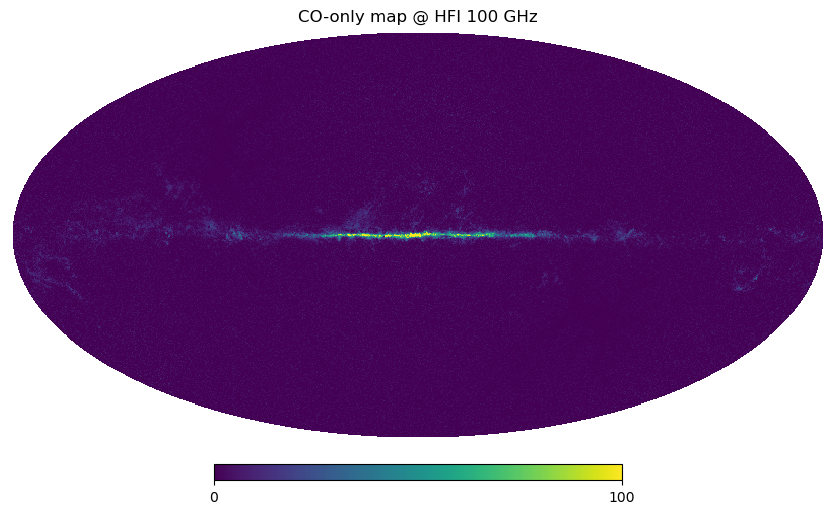

In [14]:
co_map_out = hp.ud_grade(co_map[0].value, nside_out=NSIDE_OUT)
hp.mollview(co_map_out, title="CO-only map @ HFI 100 GHz", min=0, max=100)

## Using RIMO values at 100GHz

In [16]:
bandpass_hdu = hdul_hfi[3]
wn = bandpass_hdu.data['WAVENUMBER'] * (1/u.cm)
freqs = wn.to(u.GHz, equivalencies=u.spectral())
weights = np.array(bandpass_hdu.data['TRANSMISSION'], dtype=np.float64)
# weights /= np.sum(weights) 
assert len(freqs) == len(weights)

In [17]:
freqs

<Quantity [0.0000000e+00, 5.0557536e-01, 1.0111507e+00, ..., 1.7984551e+04,
           1.7986049e+04, 1.7987547e+04] GHz>

Text(0.5, 1.0, 'RIMO HFI @ 100GHz')

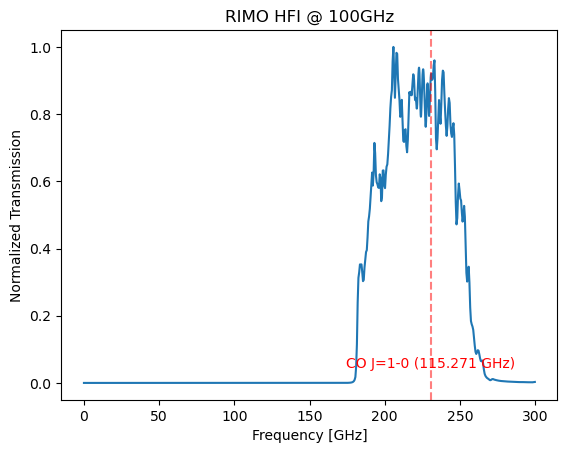

In [137]:
plt.plot(freqs[freqs.value<300], weights[freqs.value<300])
plt.axvline(230.538, color='r', linestyle='--', alpha=0.5)
plt.text(230.538, 0.045, "CO J=1-0 (115.271 GHz)", color='r', ha='center')
plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title("RIMO HFI @ 100GHz")

In [138]:
start = time()
co_map = sky.get_emission(freqs,weights)
print("CO map making time:", time() - start)

CO map making time: 3.3618788719177246


In [144]:
co_map_test = sky.get_emission(2 * u.GHz)  # no weights
print(np.isnan(co_map_test).sum())

0


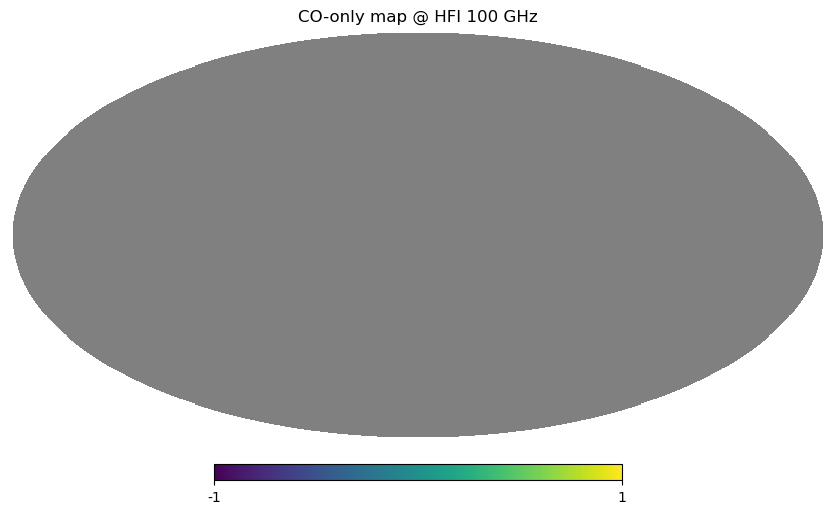

In [141]:
co_map_out = hp.ud_grade(co_map[0].value, nside_out=NSIDE_OUT)
hp.mollview(co_map_out, title="CO-only map @ HFI 100 GHz")